<a href="https://colab.research.google.com/github/SpringBoardMentor193s/SentinelNet/blob/khushalha/notebooks/cicids_bin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Import the Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

2. Load Data

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv")

print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (225745, 79)
    Destination Port   Flow Duration   Total Fwd Packets  \
0              54865               3                   2   
1              55054             109                   1   
2              55055              52                   1   
3              46236              34                   1   
4              54863               3                   2   

    Total Backward Packets  Total Length of Fwd Packets  \
0                        0                           12   
1                        1                            6   
2                        1                            6   
3                        1                            6   
4                        0                           12   

    Total Length of Bwd Packets   Fwd Packet Length Max  \
0                             0                       6   
1                             6                       6   
2                             6                       6   
3                   

In [ ]:
df.tail()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
225740,61374,61,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
225741,61378,72,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
225742,61375,75,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
225743,61323,48,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
225744,61326,68,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 225745 entries, 0 to 225744
Data columns (total 79 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0    Destination Port             225745 non-null  int64  
 1    Flow Duration                225745 non-null  int64  
 2    Total Fwd Packets            225745 non-null  int64  
 3    Total Backward Packets       225745 non-null  int64  
 4   Total Length of Fwd Packets   225745 non-null  int64  
 5    Total Length of Bwd Packets  225745 non-null  int64  
 6    Fwd Packet Length Max        225745 non-null  int64  
 7    Fwd Packet Length Min        225745 non-null  int64  
 8    Fwd Packet Length Mean       225745 non-null  float64
 9    Fwd Packet Length Std        225745 non-null  float64
 10  Bwd Packet Length Max         225745 non-null  int64  
 11   Bwd Packet Length Min        225745 non-null  int64  
 12   Bwd Packet Length Mean       225745 non-nul

3. Statistical Description of dataset

In [ ]:
df.describe()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,225745.00000,2.257450e+05,225745.000000,225745.000000,225745.000000,2.257450e+05,225745.000000,225745.000000,225745.000000,225745.000000,...,225745.000000,225745.000000,2.257450e+05,2.257450e+05,2.257450e+05,2.257450e+05,2.257450e+05,2.257450e+05,2.257450e+05,2.257450e+05
mean,8879.61946,1.624165e+07,4.874916,4.572775,939.463346,5.960477e+03,538.535693,27.882221,164.826715,214.907242,...,3.311497,21.482753,1.848261e+05,1.293436e+04,2.080849e+05,1.776201e+05,1.032214e+07,3.611943e+06,1.287813e+07,7.755355e+06
std,19754.64740,3.152437e+07,15.422874,21.755356,3249.403484,3.921834e+04,1864.128991,163.324159,504.892965,797.411073,...,12.270018,4.166799,7.979250e+05,2.102737e+05,9.002350e+05,7.842602e+05,2.185303e+07,1.275689e+07,2.692126e+07,1.983109e+07
min,0.00000,-1.000000e+00,1.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,80.00000,7.118000e+04,2.000000,1.000000,26.000000,0.000000e+00,6.000000,0.000000,6.000000,0.000000,...,1.000000,20.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,80.00000,1.452333e+06,3.000000,4.000000,30.000000,1.640000e+02,20.000000,0.000000,8.666667,5.301991,...,2.000000,20.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,80.00000,8.805237e+06,5.000000,5.000000,63.000000,1.160100e+04,34.000000,6.000000,32.000000,10.263203,...,4.000000,20.000000,1.878000e+03,0.000000e+00,1.878000e+03,1.862000e+03,8.239725e+06,0.000000e+00,8.253838e+06,7.422849e+06
max,65532.00000,1.199999e+08,1932.000000,2942.000000,183012.000000,5.172346e+06,11680.000000,1472.000000,3867.000000,6692.644993,...,1931.000000,52.000000,1.000000e+08,3.950000e+07,1.000000e+08,1.000000e+08,1.200000e+08,6.530000e+07,1.200000e+08,1.200000e+08


In [ ]:
df.describe(include='object')

,Label
count,225745
unique,2
top,DDoS
freq,128027


4. Check for missing values

In [ ]:
df.isnull().sum()

,0
Destination Port,0
Flow Duration,0
Total Fwd Packets,0
Total Backward Packets,0
Total Length of Fwd Packets,0
...,...
Idle Mean,0
Idle Std,0
Idle Max,0
Idle Min,0


In [ ]:
print("Total missing values:",df.isnull().sum().sum())

Total missing values: 4


In [ ]:
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna()

In [ ]:
print("Total missing values:",df.isnull().sum().sum())

Total missing values: 0


5. Remove unwanted columns

In [ ]:
df.columns = df.columns.str.strip()
drop_cols = ["Flow ID", "Source IP", "Source Port", "Destination IP", "Destination Port", "Timestamp"]
df = df.drop(columns=[c for c in drop_cols if c in df.columns], errors="ignore")

In [ ]:
df.head()

,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,3,2,0,12,0,6,6,6.0,0.0,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,109,1,1,6,6,6,6,6.0,0.0,6,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,52,1,1,6,6,6,6,6.0,0.0,6,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,34,1,1,6,6,6,6,6.0,0.0,6,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,3,2,0,12,0,6,6,6.0,0.0,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


6. Search for Duplicates

In [ ]:
print("Before removing duplicates:", df.shape)
df = df.drop_duplicates()
print("After removing duplicates:", df.shape)

Before removing duplicates: (225711, 78)
After removing duplicates: (221264, 78)


7. Benign VS Attack Graph

/tmp/ipython-input-2936444222.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=attack_counts.values, y=attack_counts.index, palette="viridis")


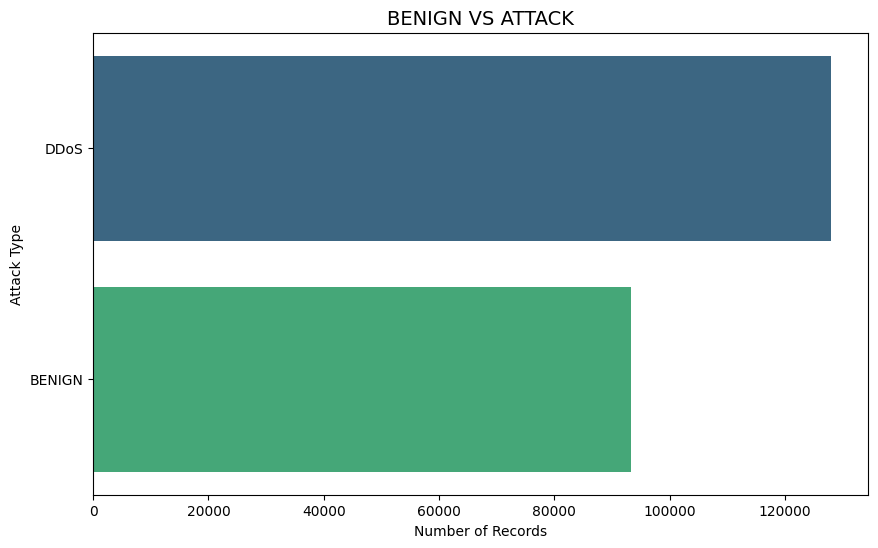

In [ ]:
attack_counts = df["Label"].value_counts().head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=attack_counts.values, y=attack_counts.index, palette="viridis")
plt.title("BENIGN VS ATTACK", fontsize=14)
plt.xlabel("Number of Records")
plt.ylabel("Attack Type")
plt.show()

8. Correlation Map

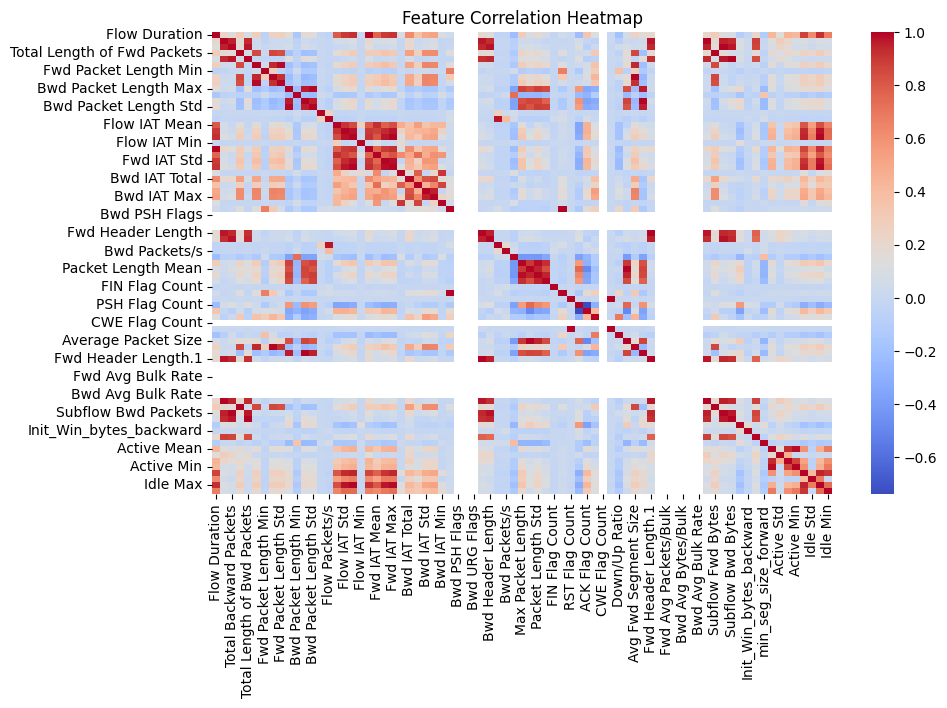

In [ ]:
plt.figure(figsize=(10,6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

9. Assigning Labels

In [ ]:
X = df.drop("Label", axis=1)
y = df["Label"]

In [ ]:
X.shape

(221264, 77)

In [ ]:
y.shape

(221264,)

10. Top 10 features of CICIDS2017

/tmp/ipython-input-1878336787.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_importances, y=top_features, palette="mako")


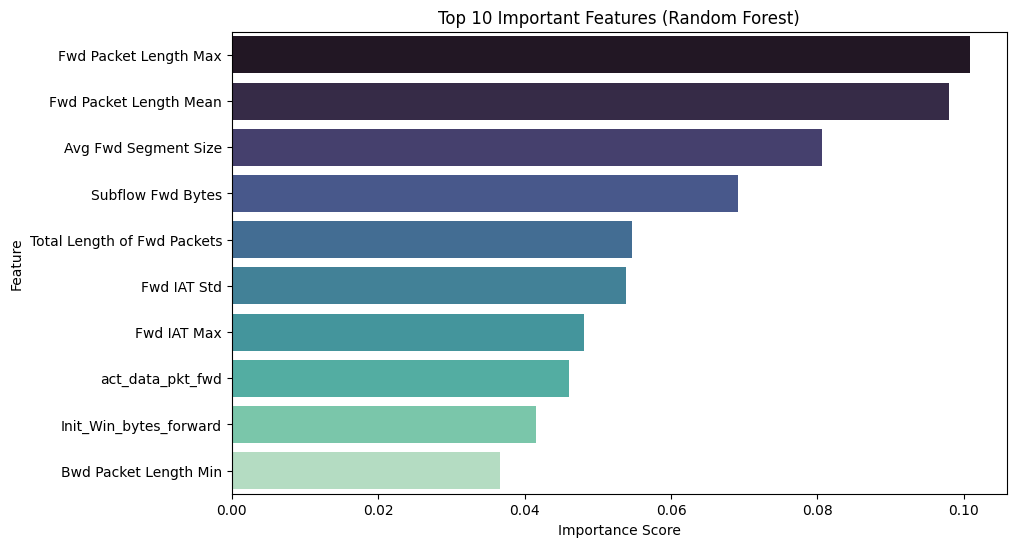

In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X, y)

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

top_features = X.columns[indices[:10]]
top_importances = importances[indices[:10]]

plt.figure(figsize=(10,6))
sns.barplot(x=top_importances, y=top_features, palette="mako")
plt.title("Top 10 Important Features (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

11. Using Label Encoder for y label

In [ ]:
le = LabelEncoder()
y = le.fit_transform(y)

12. Using Standard Scaler for x label

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

13. Applying SMOTE for imbalance rectification

In [ ]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE to the training data
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_scaled, y)

print("Shape of training data after SMOTE:", X_train_resampled.shape)
print("Shape of target variable after SMOTE:", y_train_resampled.shape)

Shape of training data after SMOTE: (256028, 77)
Shape of target variable after SMOTE: (256028,)


/tmp/ipython-input-547661679.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_resampled, palette='viridis')


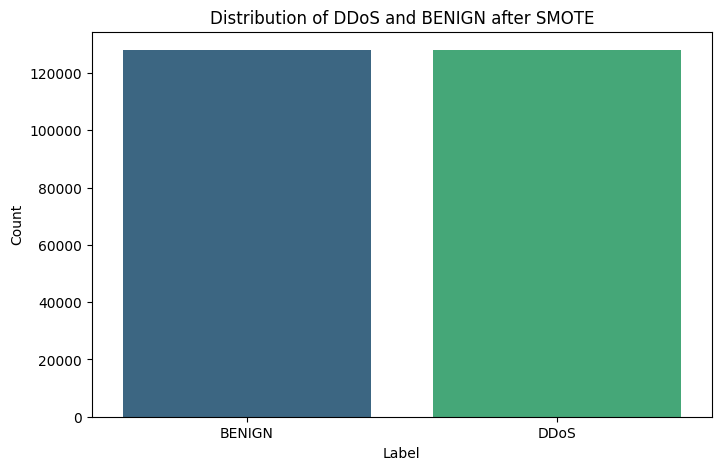

In [ ]:
# Plot the distribution of the resampled data
plt.figure(figsize=(8, 5))
sns.countplot(x=y_train_resampled, palette='viridis')
plt.title('Distribution of DDoS and BENIGN after SMOTE')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['BENIGN', 'DDoS'])
plt.show()

14. Validation Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_train_resampled, y_train_resampled, test_size=0.2, random_state=42, stratify=y_train_resampled
)

In [ ]:
X_train.shape

(204822, 77)

In [ ]:
X_test.shape

(51206, 77)

In [ ]:
y_train.shape

(204822,)

In [ ]:
y_test.shape

(51206,)

15. Model Training and Evaluation

▶ Training Logistic Regression
Training Time: 7.03s | Testing Time: 0.01s
Train Accuracy: 0.9988 | Test Accuracy: 0.9988

Classification Report (Test Data):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     25603
           1       1.00      1.00      1.00     25603

    accuracy                           1.00     51206
   macro avg       1.00      1.00      1.00     51206
weighted avg       1.00      1.00      1.00     51206



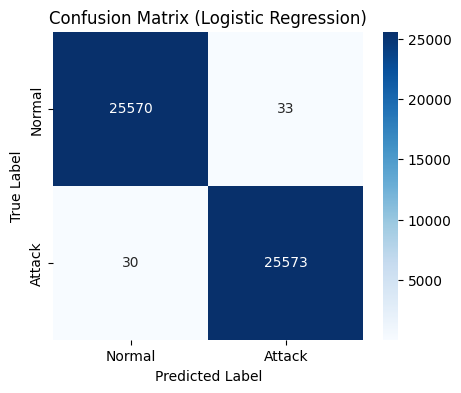

▶ Training Random Forest
Training Time: 54.68s | Testing Time: 0.22s
Train Accuracy: 1.0000 | Test Accuracy: 0.9999

Classification Report (Test Data):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     25603
           1       1.00      1.00      1.00     25603

    accuracy                           1.00     51206
   macro avg       1.00      1.00      1.00     51206
weighted avg       1.00      1.00      1.00     51206



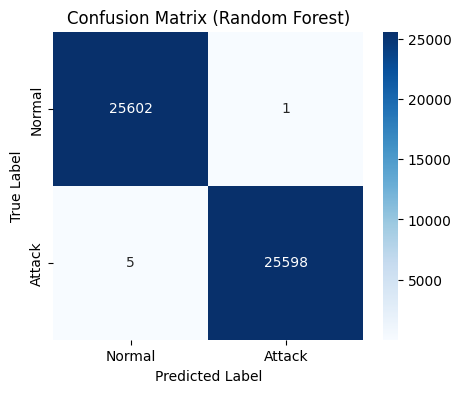

▶ Training KNN
Training Time: 0.02s | Testing Time: 102.56s
Train Accuracy: 0.9997 | Test Accuracy: 0.9995

Classification Report (Test Data):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     25603
           1       1.00      1.00      1.00     25603

    accuracy                           1.00     51206
   macro avg       1.00      1.00      1.00     51206
weighted avg       1.00      1.00      1.00     51206



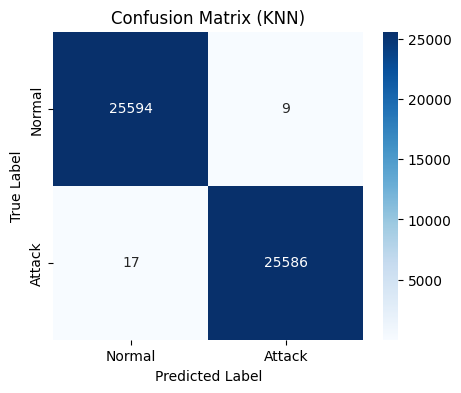

▶ Training XGBoost


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [12:25:10] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Training Time: 11.21s | Testing Time: 0.15s
Train Accuracy: 1.0000 | Test Accuracy: 0.9999

Classification Report (Test Data):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     25603
           1       1.00      1.00      1.00     25603

    accuracy                           1.00     51206
   macro avg       1.00      1.00      1.00     51206
weighted avg       1.00      1.00      1.00     51206



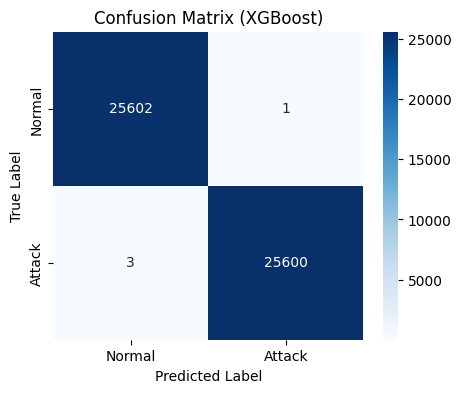

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, n_jobs=-1),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric="mlogloss", n_estimators=200, n_jobs=-1, random_state=42)
}

results = {}

# Train, evaluate, and show confusion matrix
for name, model in models.items():
    print("="*60)
    print(f"▶ Training {name}")

    # Training time
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start

    # Training performance
    y_train_pred = model.predict(X_train)
    train_acc = accuracy_score(y_train, y_train_pred)

    # Testing time
    start = time.time()
    y_test_pred = model.predict(X_test)
    test_time = time.time() - start
    test_acc = accuracy_score(y_test, y_test_pred)

    # Store results
    results[name] = {
        "Train Accuracy": train_acc,
        "Test Accuracy": test_acc,
        "Training Time": train_time,
        "Testing Time": test_time,
        "Confusion Matrix": confusion_matrix(y_test, y_test_pred),
        "Classification Report": classification_report(y_test, y_test_pred)
    }

    # Print results
    print(f"Training Time: {train_time:.2f}s | Testing Time: {test_time:.2f}s")
    print(f"Train Accuracy: {train_acc:.4f} | Test Accuracy: {test_acc:.4f}")
    print("\nClassification Report (Test Data):")
    print(classification_report(y_test, y_test_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_test_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Normal","Attack"],
                yticklabels=["Normal","Attack"])
    plt.title(f"Confusion Matrix ({name})")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

16. Comparision of the Models

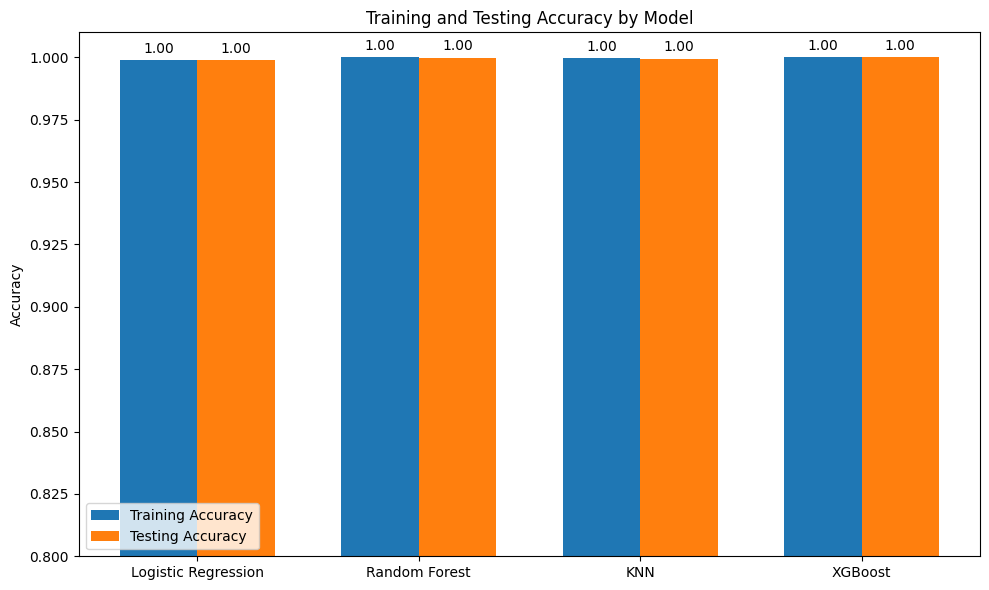

In [ ]:
model_names = list(results.keys())
train_accuracy = [metrics['Train Accuracy'] for metrics in results.values()]
test_accuracy = [metrics['Test Accuracy'] for metrics in results.values()]

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, train_accuracy, width, label='Training Accuracy')
rects2 = ax.bar(x + width/2, test_accuracy, width, label='Testing Accuracy')

ax.set_ylabel('Accuracy')
ax.set_title('Training and Testing Accuracy by Model')
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.legend()

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate('%.2f' % height,
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

plt.ylim(0.8, 1.01) # Adjust y-axis limits for better visualization
plt.tight_layout()
plt.show()

17. Plotting ROC-AUC Curve

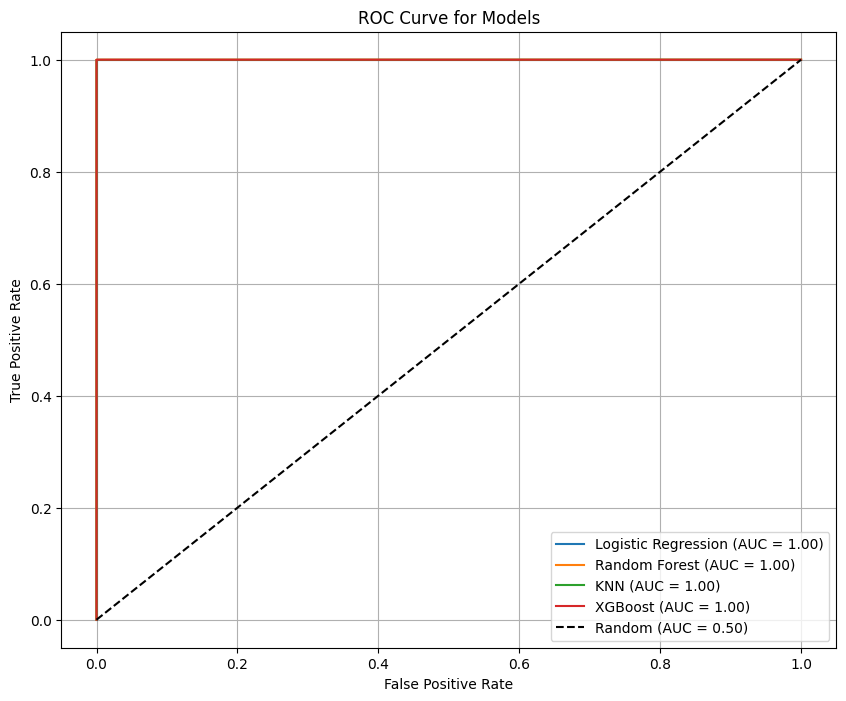

In [ ]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 8))

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test)
        fpr, tpr, _ = roc_curve(y_test, y_score)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Models')
plt.legend()
plt.grid(True)
plt.show()

18. Testing

In [ ]:
# Select an example from the test set
example_index = 44 # You can change this index to test different examples
example_data = X_test[example_index].reshape(1, -1)
true_label = y_test[example_index]

# Inverse transform the true label to its original string format
true_label_str = le.inverse_transform([true_label])[0]

print(f"Example Index: {example_index}")
print(f"True Label: {true_label_str}")
print("--- Predictions ---")

# Test with each trained model
for name, model in models.items():
    predicted_label = model.predict(example_data)[0]
    predicted_label_str = le.inverse_transform([predicted_label])[0]
    print(f"{name}: {predicted_label_str}")

Example Index: 44
True Label: DDoS
--- Predictions ---
Logistic Regression: DDoS
Random Forest: DDoS
KNN: DDoS
XGBoost: DDoS
